# Diabetes Prediction Project

## Objective
The goal of this project is to analyze medical data and build a machine learning model to predict diabetes.

## Workflow
1. Load data from CSV  
2. Store data in SQL database
3. Perform initial data extraction and cleaning using SQL
4. Perform detailed analysis using Pandas
5. Train a Machine Learning model

## Data Source 

The dataset is initially loaded from a CSV file and stored into a SQL database.
From this point onward, SQL will be used as the primary tool for data extraction and initial preprocessing, simulating a real-world data pipeline.

## Creating SQL Database

We load the dataset and store it into a SQLite database to simulate a real-world environment where data is stored in relational databases.

In [142]:
import pandas as pd
import sqlite3

# Load CSV
df = pd.read_csv("diabetes_dataset_with_notes.csv")

# Create database
conn = sqlite3.connect("diabetes.db")

# Store data in SQL
df.to_sql("patients", conn, if_exists="replace", index=False)
print("Database created successfully")


Database created successfully


## Data Extraction using SQL

We retrieve the dataset using SQL queries, simulating real-world database access.

In [143]:
query = """
SELECT *
FROM patients
"""
df_sql = pd.read_sql(query, conn)
df_sql.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."


## Data Exploration

After extracting the data using SQL, we perform an initial exploration to understand the structure, data types, and statistical properties of the dataset.

In [144]:
df_sql.dtypes

year                      int64
gender                   object
age                     float64
location                 object
race:AfricanAmerican      int64
race:Asian                int64
race:Caucasian            int64
race:Hispanic             int64
race:Other                int64
hypertension              int64
heart_disease             int64
smoking_history          object
bmi                     float64
hbA1c_level             float64
blood_glucose_level       int64
diabetes                  int64
clinical_notes           object
dtype: object

In [145]:
df_sql.describe()

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2018.360820,41.885856,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,1.345239,22.516840,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


## Data Extraction after Cleaning

We apply filtering conditions directly in SQL queries to extract a cleaned dataset without modifying the original database.

In [146]:
# Load cleaned data from SQL using filters
query = """
SELECT * FROM patients 
WHERE age >= 10 
  AND bmi <= 60
  AND blood_glucose_level IS NOT NULL
"""

df_clean = pd.read_sql(query, conn)

print(f"Final dataset size for ML: {df_clean.shape}")
df_clean.head()

Final dataset size for ML: (90124, 17)


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."


## Data Overview

We inspect the dataset structure and summary statistics after cleaning.

In [147]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90124 entries, 0 to 90123
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  90124 non-null  int64  
 1   gender                90124 non-null  object 
 2   age                   90124 non-null  float64
 3   location              90124 non-null  object 
 4   race:AfricanAmerican  90124 non-null  int64  
 5   race:Asian            90124 non-null  int64  
 6   race:Caucasian        90124 non-null  int64  
 7   race:Hispanic         90124 non-null  int64  
 8   race:Other            90124 non-null  int64  
 9   hypertension          90124 non-null  int64  
 10  heart_disease         90124 non-null  int64  
 11  smoking_history       90124 non-null  object 
 12  bmi                   90124 non-null  float64
 13  hbA1c_level           90124 non-null  float64
 14  blood_glucose_level   90124 non-null  int64  
 15  diabetes           

In [148]:
df_clean.describe()

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,90124.000000,90124.000000,90124.000000,90124.000000,90124.000000,90124.000000,90124.000000,90124.000000,90124.000000,90124.000000,90124.000000,90124.000000,90124.000000
mean,2018.362145,45.948604,0.202155,0.200834,0.198771,0.198848,0.199392,0.082786,0.043629,28.164832,5.539253,138.604833,0.093660
std,1.344214,19.808466,0.401609,0.400627,0.399077,0.399136,0.399545,0.275560,0.204269,6.027523,1.079163,41.276116,0.291357
min,2015.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.930000,4.800000,100.000000,0.000000
50%,2019.000000,46.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,61.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.230000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,60.000000,9.000000,300.000000,1.000000


## Checking Target Distribution

We analyze the distribution of the target variable (diabetes) to understand if the dataset is balanced.

In [149]:
df_clean["diabetes"].value_counts()

diabetes
0    81683
1     8441
Name: count, dtype: int64

In [150]:
df_clean["diabetes"].value_counts(normalize=True)

diabetes
0    0.90634
1    0.09366
Name: proportion, dtype: float64

## Feature Relationship with Target

We analyze how numerical variables differ between patients with and without diabetes to identify important predictors.

In [151]:
df_clean.groupby("diabetes").mean(numeric_only=True)

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level
diabetes,,,,,,,,,,,,
0,2018.363515,44.380116,0.201535,0.200384,0.198977,0.199050,0.200054,0.065901,0.032687,27.781553,5.395203,132.879387
1,2018.348892,61.126762,0.208151,0.205189,0.196778,0.196896,0.192987,0.246179,0.149508,31.873797,6.933207,194.009596


## Smoking Behavior Analysis

We explore how smoking habits relate to diabetes prevalence.

In [152]:
df_clean.groupby("smoking_history")["diabetes"].mean()

smoking_history
No Info        0.052453
current        0.101935
ever           0.117618
former         0.169933
never          0.097855
not current    0.109992
Name: diabetes, dtype: float64

## Age Distribution 

We analyze the distribution of patient ages to understand the population and detect any patterns.

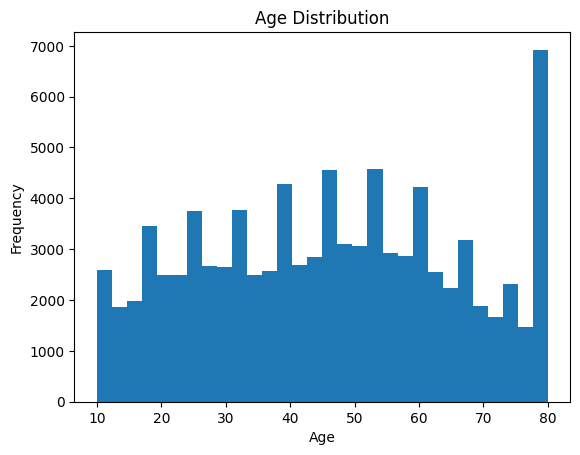

In [153]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(df_clean["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The age distribution shows a higher concentration of patients in older age groups, particularly near the upper range.

This pattern is consistent with medical knowledge, as the risk of diabetes tends to increase with age. The presence of a significant number of older patients makes the dataset suitable for analyzing age-related risk factors.

## BMI Distribution

We analyze the distribution of Body Mass Index (BMI) to understand weight patterns in the dataset.

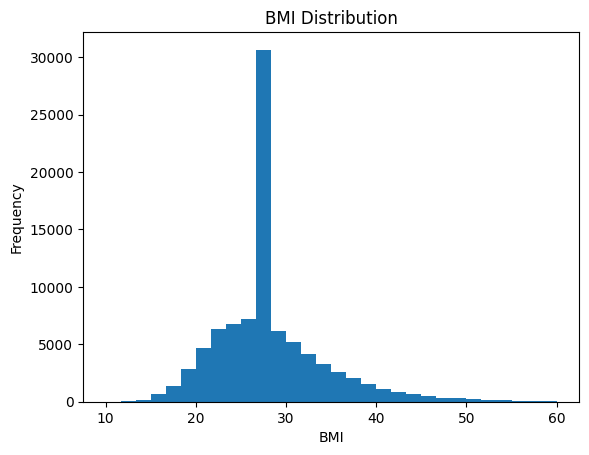

In [154]:
plt.figure()
plt.hist(df_clean["bmi"], bins=30)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

The BMI distribution is centered around values close to 28, indicating that a large portion of the population falls within the overweight category.

This is a relevant finding, as higher BMI is a known risk factor for diabetes. The distribution appears relatively normal, with fewer extreme values, suggesting that the data cleaning process successfully removed outliers.

## Blood Glucose Distribution

We analyze the distribution of blood glucose levels, which is a key indicator for diabetes.

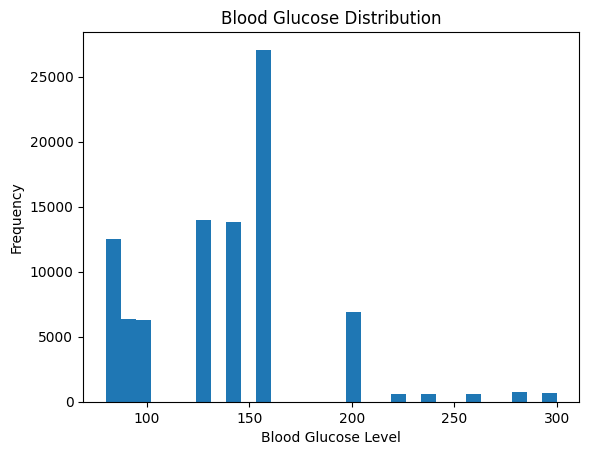

In [155]:
plt.figure()
plt.hist(df_clean["blood_glucose_level"], bins=30)
plt.title("Blood Glucose Distribution")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Frequency")
plt.show()

The distribution of blood glucose levels shows a strong concentration around mid-range values, particularly between 120 and 160.

There is a noticeable right-skewed pattern, with fewer observations at higher glucose levels (above 200). These higher values are clinically significant, as they are often associated with increased risk of diabetes.

Overall, the distribution reflects realistic medical patterns, where most individuals fall within moderate ranges while a smaller portion exhibits elevated glucose levels.

## Blood Glucose vs Diabetes

We compare blood glucose levels between diabetic and non-diabetic and non-diabetic patients to understand its predictive power.

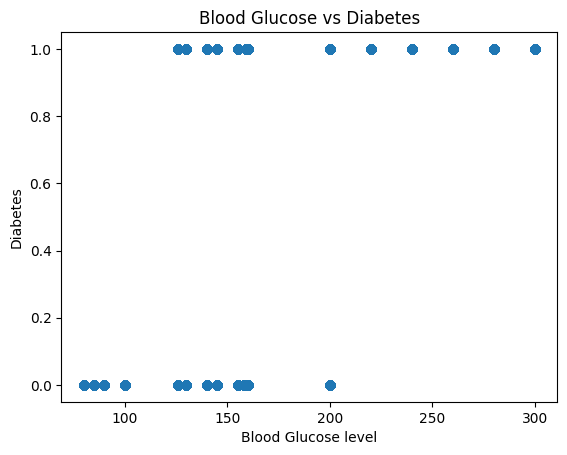

In [156]:
plt.figure()
plt.scatter(df_clean["blood_glucose_level"], df_clean["diabetes"])
plt.title("Blood Glucose vs Diabetes")
plt.xlabel("Blood Glucose level")
plt.ylabel("Diabetes")
plt.show()

The relationship between blood glucose levels and diabetes shows a clear pattern.

Patients without diabetes (0) are mostly concentrated in lower glucose ranges, generally below 140, although some extend up to around 200.

In contrast, patients with diabetes (1) tend to appear more frequently at higher glucose levels, starting around 125 and extending up to 300.

There is some overlap between the two groups, which is expected in real-world medical data. However, higher glucose values are clearly associated with a greater likelihood of diabetes, indicating that this feature has strong predictive power for the model.

## HbA1c vs Diabetes 

We analyze the relationship between  HbA1c levels and diabetes, as it is one of the most important clinical indicators.

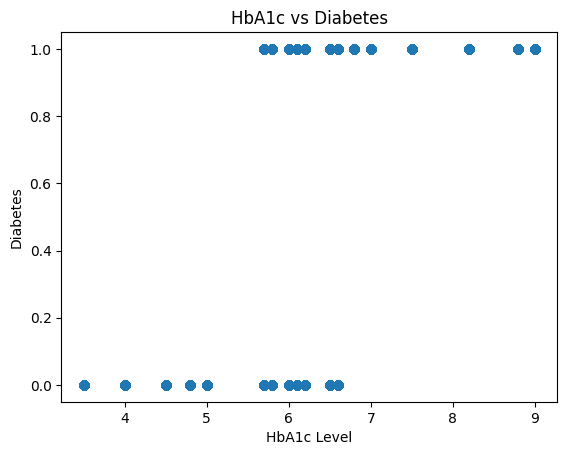

In [157]:
plt.figure()
plt.scatter(df_clean["hbA1c_level"], df_clean["diabetes"])
plt.title("HbA1c vs Diabetes")
plt.xlabel("HbA1c Level")
plt.ylabel("Diabetes")
plt.show()

The relationship between HbA1c levels and diabetes shows a clear but not perfectly separated pattern.

Patients without diabetes (0) are mostly concentrated at lower HbA1c levels, generally below 5.7, although some values extend into higher ranges.

Patients with diabetes (1) appear more frequently at higher HbA1c levels, typically starting around 5.7–5.8 and increasing up to the highest values in the dataset.

There is noticeable overlap between both groups, which is expected in real-world medical data. However, higher HbA1c levels are strongly associated with diabetes, making this feature one of the most important predictors for the model.

## Preparing Data for Machine Learning

We now prepare the dataset for model training by creating a working copy.

In [158]:
df_ml = df_clean.copy()

## Encoding Categorical Variables

We convert categorical variables into numerical format using one-hot encoding, which is required for machine learning models.

In [159]:
df_ml = pd.get_dummies(df_ml, columns=["gender", "smoking_history"], drop_first=True)

In [160]:
df_ml.head()

,year,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,...,blood_glucose_level,diabetes,clinical_notes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,2020,32.0,Alabama,0,0,0,0,1,0,0,...,100,0,"Overweight, advised dietary and exercise modif...",False,False,False,False,False,True,False
1,2015,29.0,Alabama,0,1,0,0,0,0,0,...,90,0,Healthy BMI range.,False,False,False,False,False,True,False
2,2015,18.0,Alabama,0,0,0,0,1,0,0,...,160,0,"Young patient, generally lower risk but needs ...",True,False,False,False,False,True,False
3,2015,41.0,Alabama,0,0,1,0,0,0,0,...,159,0,"Overweight, advised dietary and exercise modif...",True,False,False,False,False,True,False
4,2016,52.0,Alabama,1,0,0,0,0,0,0,...,90,0,"Healthy BMI range. High HbA1c level, indicativ...",False,False,False,False,False,True,False


## Dropping Irrelevant Columns

We remove columns that are not useful for prediction, such as text data and non-informative identifiers.

In [161]:
df_ml = df_ml.drop(columns=["clinical_notes", "location"])

In [162]:
df_ml.head()

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,2020,32.0,0,0,0,0,1,0,0,27.32,5.0,100,0,False,False,False,False,False,True,False
1,2015,29.0,0,1,0,0,0,0,0,19.95,5.0,90,0,False,False,False,False,False,True,False
2,2015,18.0,0,0,0,0,1,0,0,23.76,4.8,160,0,True,False,False,False,False,True,False
3,2015,41.0,0,0,1,0,0,0,0,27.32,4.0,159,0,True,False,False,False,False,True,False
4,2016,52.0,1,0,0,0,0,0,0,23.75,6.5,90,0,False,False,False,False,False,True,False


## Defining Features and Target

We separate the dataset into input features (X) and the target variable (y).

In [163]:
X = df_ml.drop("diabetes", axis=1)
y = df_ml["diabetes"]
X.shape, y.shape

((90124, 19), (90124,))

## Train-Test Split

We split the dataset into training and testing sets to evaluate model performance on unseen data.

In [164]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((72099, 19), (18025, 19))

## Feature Scaling

We standardize numerical features to improve model performance, especially for algorithms like Logistic Regression.

In [165]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train[:5]

array([[ 0.47599248,  1.46971251, -0.50513536,  1.98981103, -0.4963174 ,
        -0.49720712, -0.49876875,  3.34133228, -0.21423891,  0.28584815,
         1.35441568,  3.42958475,  1.21940322, -0.01290215, -0.33732846,
         4.64166222, -0.34002546, -0.77691041, -0.27555005],
       [ 0.47599248,  0.30644019, -0.50513536, -0.50256029, -0.4963174 ,
        -0.49720712,  2.00493716, -0.29928182, -0.21423891,  0.73845756,
        -0.49979168,  0.03356234,  1.21940322, -0.01290215,  2.96446966,
        -0.21544006, -0.34002546, -0.77691041, -0.27555005],
       [ 0.47599248,  0.71105665, -0.50513536, -0.50256029,  2.01483968,
        -0.49720712, -0.49876875, -0.29928182, -0.21423891,  0.04710912,
         0.89086384, -0.93672977,  1.21940322, -0.01290215, -0.33732846,
        -0.21544006, -0.34002546, -0.77691041, -0.27555005],
       [ 0.47599248, -1.16029448, -0.50513536, -0.50256029, -0.4963174 ,
         2.01123428, -0.49876875, -0.29928182, -0.21423891, -0.14189261,
         0.983

## Logistic Regression Model

We train a baseline model using Logistic Regression. Due to class imbalance, we use class_weight='balanced'.

In [166]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Model Evaluation 

We evaluate the model using accuracy, classification report, and confusion matrix.
Accuracy alone is not sufficient due to class imbalance.

In [167]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8847156726768377


## Classification Report

We evaluate model performance in detail, focusing on precision, recall, and F1-score.

In [168]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.89      0.93     16285
           1       0.45      0.87      0.59      1740

    accuracy                           0.88     18025
   macro avg       0.72      0.88      0.76     18025
weighted avg       0.93      0.88      0.90     18025



The model achieved high recall (0.87) for diabetes detection, prioritizing the identification of positive cases, which is critical in healthcare scenarios.

## Confusion Matrix

We analyze the number of correct and incorrect predictions to better understand model performance.

In [169]:
print(confusion_matrix(y_test, y_pred))

[[14431  1854]
 [  224  1516]]


## Model Performance Summary

The model shows strong performance in detecting diabetes cases, with a high recall and a low number of false negatives.
Although the number of false positives is higher, this is acceptable in a medical context where identifying potential cases is more important than avoiding false alarms.
Overall, the model prioritizes sensitivity, making it suitable for early detection scenarios.

## Random Forest Model

We train a more advanced model using Random Forest to improve performance and capture non-linear relationships.

In [170]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Random Forest Evaluation

We evaluate the Random Forest model to compare its performance with Logistic Regression.

In [171]:
y_pred_rf = rf_model.predict(X_test)
from sklearn.metrics import accuracy_score
print("Accuracy (Random Forest):", accuracy_score(y_test, y_pred_rf))

Accuracy (Random Forest): 0.9690984743411928


## Random Forest Classification Report

We analyze precision, recall, and F1-score to better evaluate model performance, especially for the minority class.

In [172]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     16285
           1       0.98      0.69      0.81      1740

    accuracy                           0.97     18025
   macro avg       0.98      0.85      0.90     18025
weighted avg       0.97      0.97      0.97     18025



## Model Comparison

Two models were evaluated: Logistic Regression and Random Forest.
Logistic Regression achieved a higher recall (0.87) for diabetes detection, making it more effective at identifying positive cases. However, it produced more false positives.
Random Forest achieved higher overall accuracy (0.97) and precision, but its recall for diabetes was significantly lower (0.69), meaning it failed to detect a larger number of true diabetes cases.
In a healthcare context, recall is more critical than accuracy, as missing a diagnosis can have serious consequences. Therefore, Logistic Regression was selected as the preferred model.